In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

clinical_path = PROCESSED_DIR / "GSE238110_DOG2_clinical_matched_indexed.csv"
clinical = pd.read_csv(clinical_path, index_col=0)

print(clinical.shape)
display(clinical.head())
display(pd.DataFrame({"column": clinical.columns}))


(186, 25)


,Patient ID,Tumor Location,Site,age,weight,breed,gender,PH,ALP,Group,DFS_time,DFS_status,OS_time,OS_status,treatment,primary_immune_subtype,patient_id_clean,sample_id_bracket,sample_type,dfi_time,dfi_event,os_time,os_event,dfi_event_365d,dfi_event_540d
original_sample_column,,,,,,,,,,,,,,,,,,,,,,,,,
100_0514_tumor,514,Left distal radius,UW,5.5,42.7,Mixed Breed,Spayed Female,0,Normal,NPHNALP,33,0,117,1,SOC,ID,514,100_0514_tumor,primary_or_tumor,33,0,117,1,NaN,NaN
101_0518_tumor,518,Left proximal humerus,UW,8.3,44.3,Rottweiler,Spayed Female,1,Elevated,PHEALP,12,0,248,0,SOC,IE-ECM,518,101_0518_tumor,primary_or_tumor,12,0,248,0,NaN,NaN
102_0619_tumor,619,Left distal tibia,OSU,7.5,30.8,Mixed Breed,Spayed Female,0,Normal,NPHNALP,63,1,622,0,SOC,IE-ECM,619,102_0619_tumor,primary_or_tumor,63,1,622,0,1.0,1.0
103_0639_tumor,639,Left distal femur,OSU,6.9,36.2,Greyhound,Castrated Male,0,Normal,NPHNALP,234,1,283,1,SOC,ID,639,103_0639_tumor,primary_or_tumor,234,1,283,1,1.0,1.0
104_0702_tumor,702,Right distal ulna,UIL,9.5,33.2,Labrador Retriever,Castrated Male,0,Normal,NPHNALP,153,1,171,0,SOC,IE-ECM,702,104_0702_tumor,primary_or_tumor,153,1,171,0,1.0,1.0


,column
0,Patient ID
1,Tumor Location
2,Site
3,age
4,weight
5,breed
6,gender
7,PH
8,ALP
9,Group


In [2]:
for col in ["dfi_time", "dfi_event", "os_time", "os_event", "age", "weight", "PH"]:
    if col in clinical.columns:
        clinical[col] = pd.to_numeric(clinical[col], errors="coerce")

endpoint_summary = pd.DataFrame({
    "endpoint": ["DFI", "OS"],
    "time_column": ["dfi_time", "os_time"],
    "event_column": ["dfi_event", "os_event"],
    "n": [
        clinical[["dfi_time", "dfi_event"]].dropna().shape[0],
        clinical[["os_time", "os_event"]].dropna().shape[0],
    ],
    "events": [
        int(clinical["dfi_event"].sum()),
        int(clinical["os_event"].sum()),
    ],
    "censored": [
        int((clinical["dfi_event"] == 0).sum()),
        int((clinical["os_event"] == 0).sum()),
    ],
    "median_time": [
        clinical["dfi_time"].median(),
        clinical["os_time"].median(),
    ],
})

display(endpoint_summary)
endpoint_summary.to_csv(PROCESSED_DIR / "DOG2_endpoint_summary.csv", index=False)


,endpoint,time_column,event_column,n,events,censored,median_time
0,DFI,dfi_time,dfi_event,186,143,43,154.0
1,OS,os_time,os_event,186,124,62,227.5


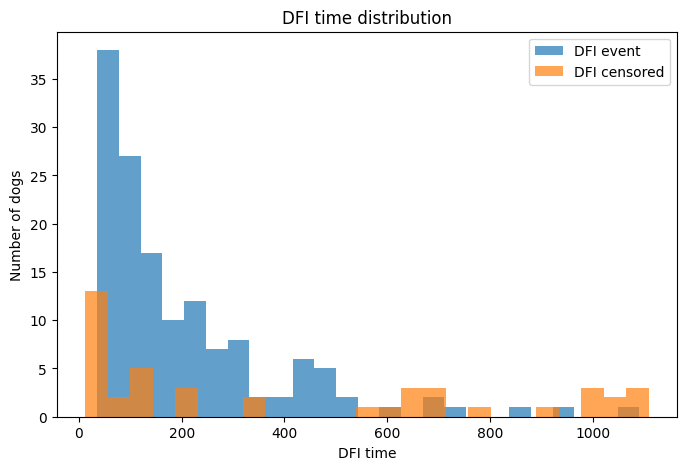

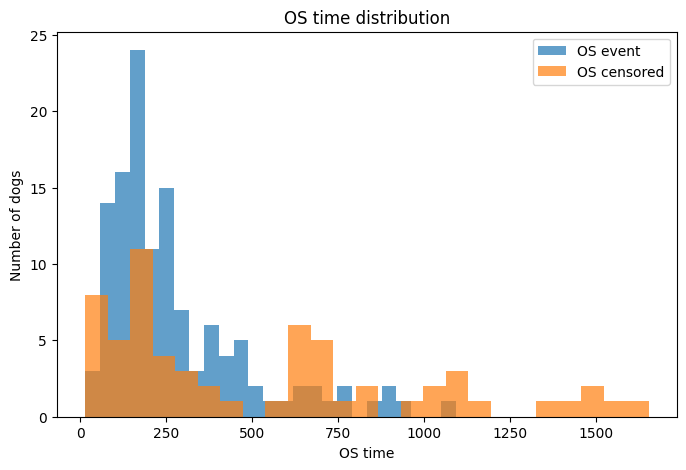

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(clinical.loc[clinical["dfi_event"] == 1, "dfi_time"], bins=25, alpha=0.7, label="DFI event")
ax.hist(clinical.loc[clinical["dfi_event"] == 0, "dfi_time"], bins=25, alpha=0.7, label="DFI censored")
ax.set_xlabel("DFI time")
ax.set_ylabel("Number of dogs")
ax.set_title("DFI time distribution")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(clinical.loc[clinical["os_event"] == 1, "os_time"], bins=25, alpha=0.7, label="OS event")
ax.hist(clinical.loc[clinical["os_event"] == 0, "os_time"], bins=25, alpha=0.7, label="OS censored")
ax.set_xlabel("OS time")
ax.set_ylabel("Number of dogs")
ax.set_title("OS time distribution")
ax.legend()
plt.show()


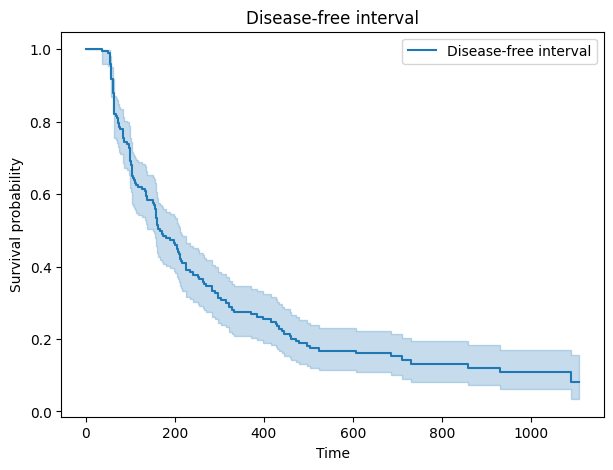

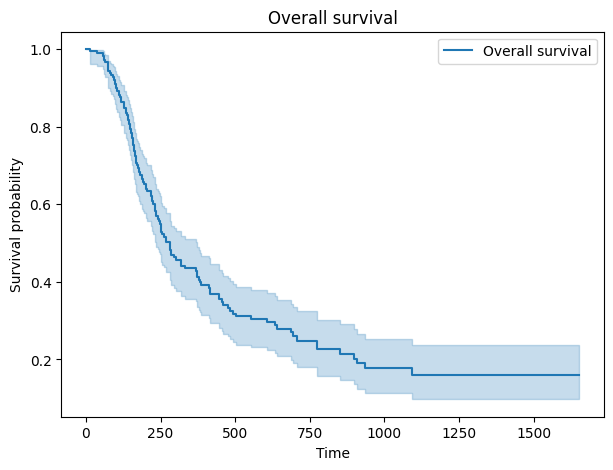

In [4]:
def plot_km(df, time_col, event_col, title):
    kmf = KaplanMeierFitter()
    valid = df[[time_col, event_col]].dropna()
    kmf.fit(valid[time_col], valid[event_col], label=title)

    ax = kmf.plot_survival_function(figsize=(7, 5))
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    ax.set_title(title)
    plt.show()

plot_km(clinical, "dfi_time", "dfi_event", "Disease-free interval")
plot_km(clinical, "os_time", "os_event", "Overall survival")


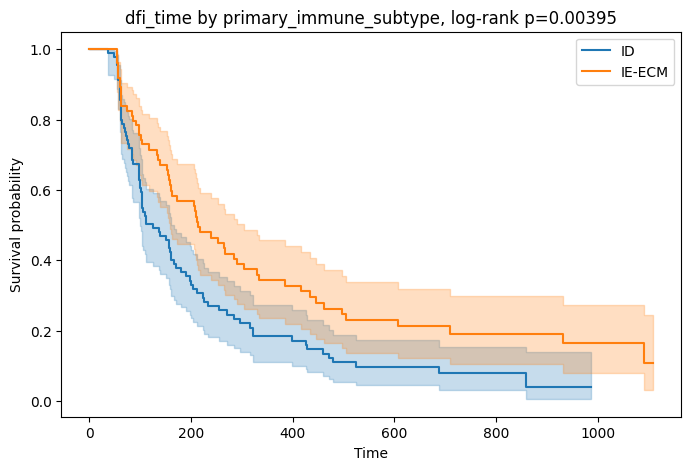

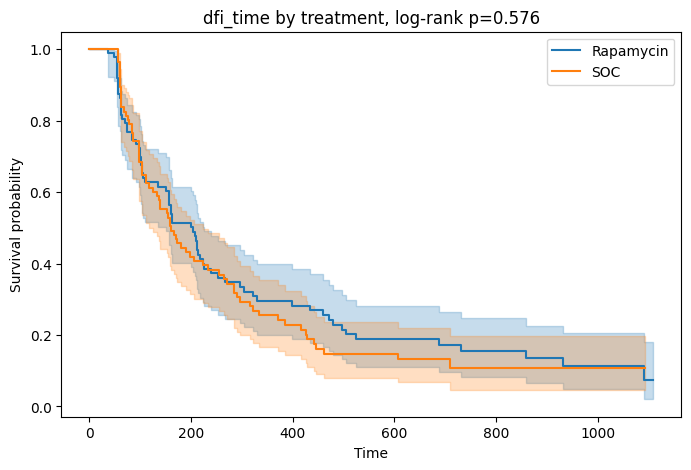

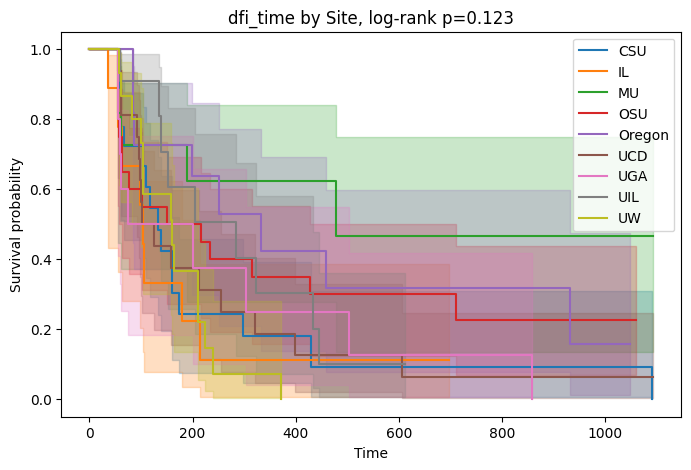

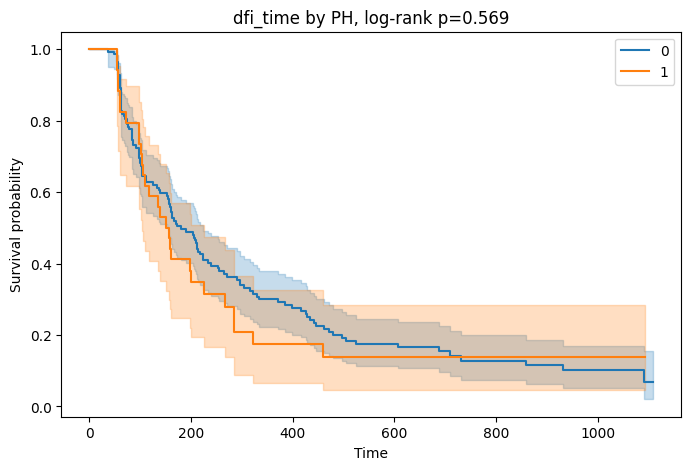

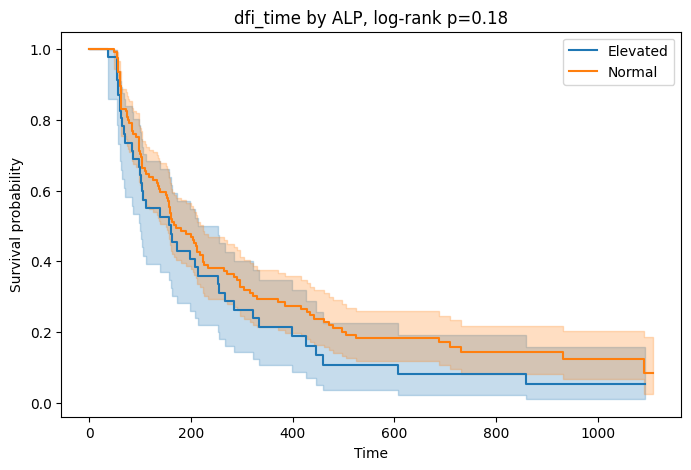

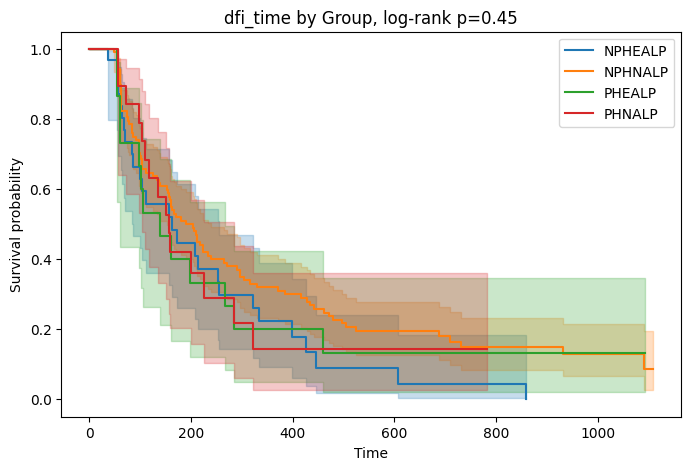

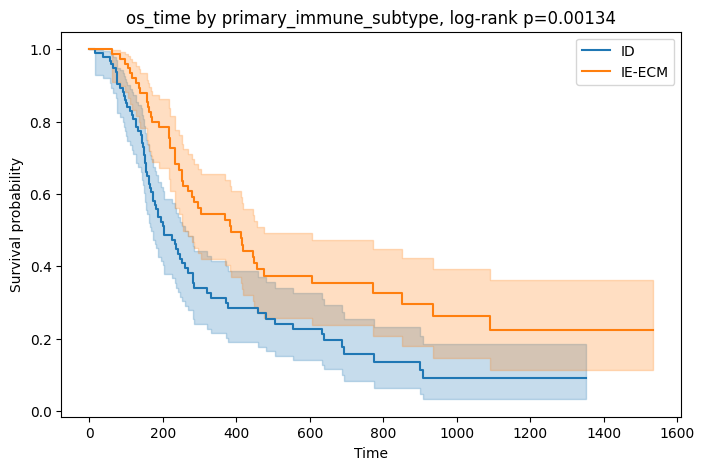

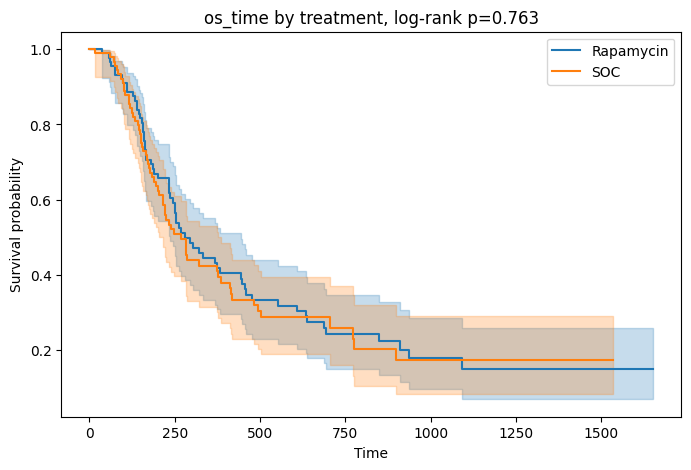

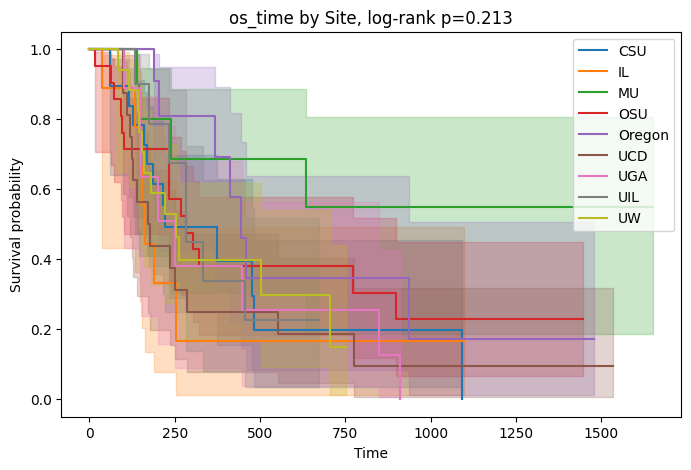

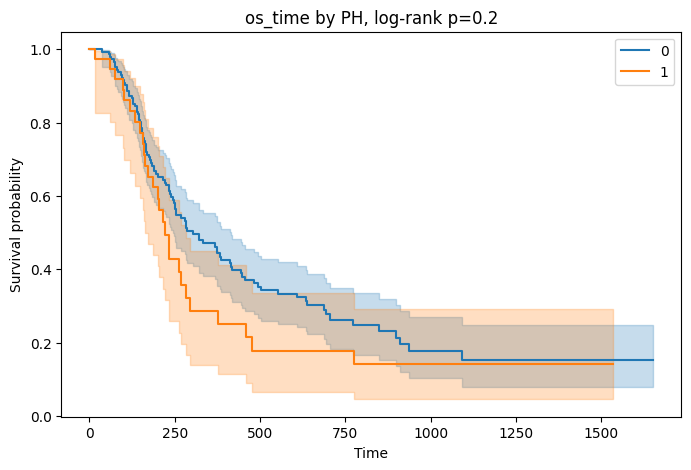

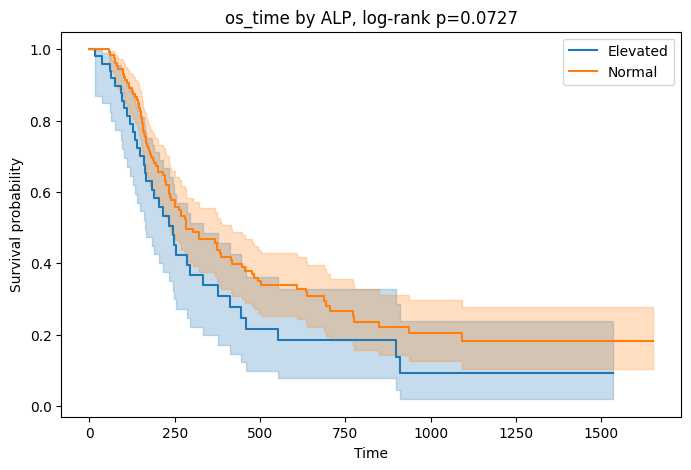

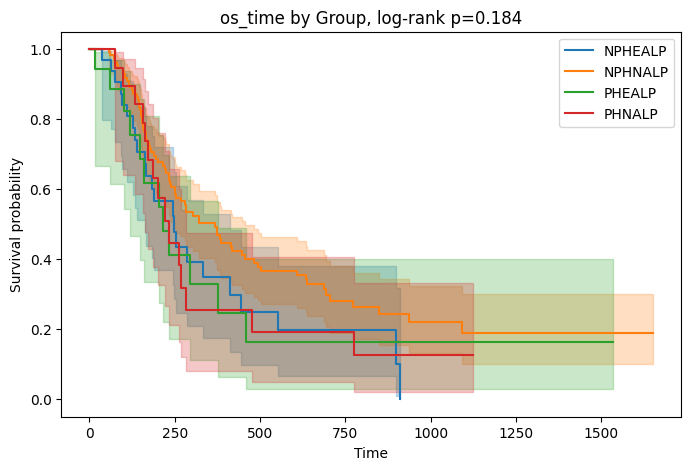

,group_col,time_col,event_col,n,n_groups,logrank_p
0,primary_immune_subtype,dfi_time,dfi_event,177,2,0.003954
1,treatment,dfi_time,dfi_event,186,2,0.575985
2,Site,dfi_time,dfi_event,131,9,0.123371
3,PH,dfi_time,dfi_event,186,2,0.568796
4,ALP,dfi_time,dfi_event,184,2,0.180048
5,Group,dfi_time,dfi_event,186,4,0.449924
6,primary_immune_subtype,os_time,os_event,177,2,0.001338
7,treatment,os_time,os_event,186,2,0.763371
8,Site,os_time,os_event,131,9,0.212504
9,PH,os_time,os_event,186,2,0.199808


In [5]:
def plot_grouped_km(df, group_col, time_col, event_col, min_group_size=10):
    use = df[[group_col, time_col, event_col]].dropna().copy()
    group_counts = use[group_col].value_counts()
    keep_groups = group_counts[group_counts >= min_group_size].index
    use = use[use[group_col].isin(keep_groups)]

    if use[group_col].nunique() < 2:
        print(f"Skipping {group_col}: fewer than two usable groups")
        return None

    kmf = KaplanMeierFitter()
    ax = plt.figure(figsize=(8, 5)).gca()

    for group, part in use.groupby(group_col):
        kmf.fit(part[time_col], part[event_col], label=str(group))
        kmf.plot_survival_function(ax=ax)

    result = multivariate_logrank_test(
        use[time_col],
        use[group_col],
        use[event_col],
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    ax.set_title(f"{time_col} by {group_col}, log-rank p={result.p_value:.3g}")
    plt.show()

    return {
        "group_col": group_col,
        "time_col": time_col,
        "event_col": event_col,
        "n": use.shape[0],
        "n_groups": use[group_col].nunique(),
        "logrank_p": result.p_value,
    }


group_cols = ["primary_immune_subtype", "treatment", "Site", "PH", "ALP", "Group"]

km_results = []

for group_col in group_cols:
    if group_col in clinical.columns:
        out = plot_grouped_km(clinical, group_col, "dfi_time", "dfi_event")
        if out is not None:
            km_results.append(out)

for group_col in group_cols:
    if group_col in clinical.columns:
        out = plot_grouped_km(clinical, group_col, "os_time", "os_event")
        if out is not None:
            km_results.append(out)

km_results = pd.DataFrame(km_results)
display(km_results)
km_results.to_csv(PROCESSED_DIR / "DOG2_grouped_km_logrank_results.csv", index=False)


In [6]:
def fit_univariate_cox(df, time_col, event_col, variable):
    use = df[[time_col, event_col, variable]].dropna().copy()

    if use.shape[0] < 30:
        return None

    if use[variable].nunique() < 2:
        return None

    if use[variable].dtype == "object" or str(use[variable].dtype) == "category":
        use = pd.get_dummies(use, columns=[variable], drop_first=True)

    covariates = [c for c in use.columns if c not in [time_col, event_col]]
    results = []

    for cov in covariates:
        tmp = use[[time_col, event_col, cov]].dropna()
        if tmp[cov].nunique() < 2:
            continue

        cph = CoxPHFitter()
        try:
            cph.fit(tmp, duration_col=time_col, event_col=event_col)
            row = cph.summary.loc[cov].to_dict()
            row["variable"] = variable
            row["term"] = cov
            row["n"] = tmp.shape[0]
            results.append(row)
        except Exception as e:
            results.append({
                "variable": variable,
                "term": cov,
                "n": tmp.shape[0],
                "error": str(e),
            })

    return results


candidate_clinical_vars = [
    "age",
    "weight",
    "PH",
    "ALP",
    "Group",
    "Site",
    "treatment",
    "primary_immune_subtype",
]

all_results = []

for endpoint_name, time_col, event_col in [
    ("DFI", "dfi_time", "dfi_event"),
    ("OS", "os_time", "os_event"),
]:
    for var in candidate_clinical_vars:
        if var in clinical.columns:
            res = fit_univariate_cox(clinical, time_col, event_col, var)
            if res is not None:
                for r in res:
                    r["endpoint"] = endpoint_name
                all_results.extend(res)

cox_results = pd.DataFrame(all_results)
display(cox_results.sort_values("p") if "p" in cox_results.columns else cox_results)

cox_results.to_csv(PROCESSED_DIR / "DOG2_univariate_clinical_cox_results.csv", index=False)


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p),variable,term,n,endpoint
1,0.024497,1.024800e+00,0.007266,0.010256,0.038738,1.010309,1.039498,0.0,3.371500,0.000748,10.385444,weight,weight,185,DFI
63,-0.491025,6.119988e-01,0.185649,-0.854891,-0.127159,0.425330,0.880593,0.0,-2.644908,0.008171,6.935218,primary_immune_subtype,primary_immune_subtype_IE-ECM,186,OS
31,-0.376628,6.861714e-01,0.171816,-0.713382,-0.039874,0.489984,0.960911,0.0,-2.192036,0.028377,5.139138,primary_immune_subtype,primary_immune_subtype_IE-ECM,186,DFI
38,-0.398296,6.714631e-01,0.184064,-0.759054,-0.037538,0.468109,0.963158,0.0,-2.163906,0.030472,5.036391,Group,Group_NPHNALP,186,OS
46,-1.068190,3.436299e-01,0.510632,-2.069010,-0.067370,0.126311,0.934849,0.0,-2.091900,0.036448,4.778036,Site,Site_MU,186,OS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0.030602,1.031075e+00,1.005371,-1.939889,2.001092,0.143720,7.397130,0.0,0.030438,0.975718,0.035465,ALP,ALP_normal,186,DFI
28,-15.927816,1.209588e-07,2141.738744,-4213.658619,4181.802987,0.000000,inf,0.0,-0.007437,0.994066,0.008586,Site,Site_¬†IL,186,DFI
4,-15.927816,1.209588e-07,2141.738744,-4213.658619,4181.802987,0.000000,inf,0.0,-0.007437,0.994066,0.008586,ALP,ALP_Normal¬†,186,DFI
36,-15.923609,1.214687e-07,2461.020525,-4839.435204,4807.587986,0.000000,inf,0.0,-0.006470,0.994837,0.007467,ALP,ALP_Normal¬†,186,OS
